# PROJECT : House Price Prediction
# Dataset: California Housing (sklearn built-in)
# Model: Linear Regression

# SECTION 1: IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
 
import warnings
warnings.filterwarnings("ignore")

# SECTION 2: LOAD DATASET

In [2]:
housing = fetch_california_housing()
 
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target
 
print("Shape:", df.shape)

Shape: (20640, 9)


In [3]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


# SECTION 3: DATA CLEANING

In [4]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


In [5]:
print("\nBasic statistics:")
print(df.describe().round(2))


Basic statistics:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude     Price  
count  20640.00   20640.00  20640.00  
mean      35.63    -119.57      2.07  
std        2.14       2.00      1.15  
min       32.54    -124.35      0.15  
25%       33.93    -121.80      1.20  
50%       34.26    -118.49      1.80  
75%       37.71    -118.01      2.65  
max       41.95    -

In [6]:
# Remove outliers beyond 99th percentile for skewed columns
df = df[df["AveRooms"] < df["AveRooms"].quantile(0.99)]
df = df[df["AveOccup"] < df["AveOccup"].quantile(0.99)]
 
print(f"\nRows after outlier removal: {df.shape[0]}")


Rows after outlier removal: 20228


# SECTION 4: EXPLORATORY DATA ANALYSIS (EDA)

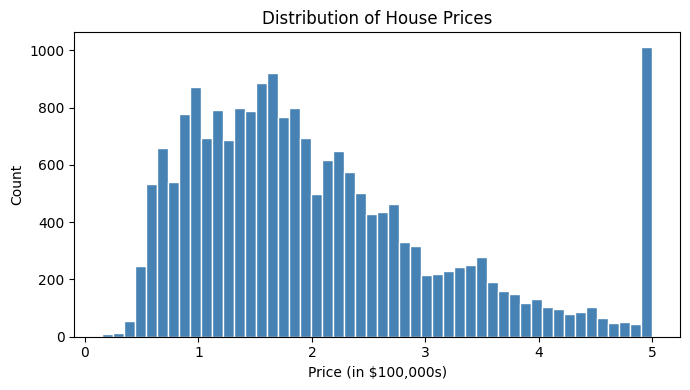

In [7]:
# Plot 1: Price Distribution
plt.figure(figsize=(7, 4))
df["Price"].plot(kind="hist", bins=50, color="steelblue", edgecolor="white")
plt.title("Distribution of House Prices")
plt.xlabel("Price (in $100,000s)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("plot1_price_distribution.png")
plt.show()

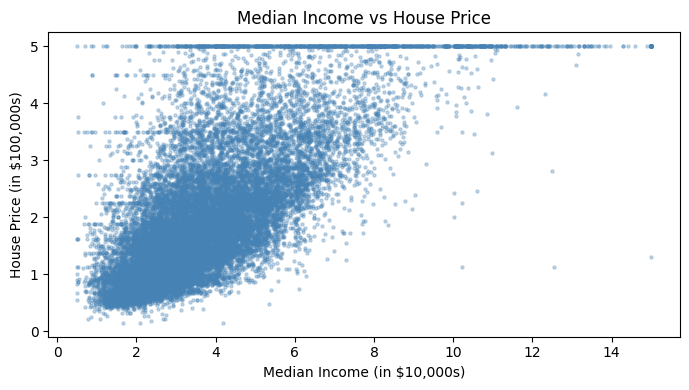

In [8]:
# Plot 2: Median Income vs Price
plt.figure(figsize=(7, 4))
plt.scatter(df["MedInc"], df["Price"], alpha=0.3, color="steelblue", s=5)
plt.title("Median Income vs House Price")
plt.xlabel("Median Income (in $10,000s)")
plt.ylabel("House Price (in $100,000s)")
plt.tight_layout()
plt.savefig("plot2_income_vs_price.png")
plt.show()

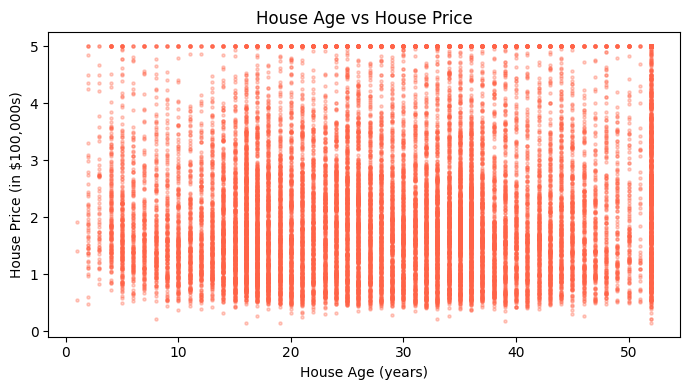

In [9]:
# Plot 3: House Age vs Price
plt.figure(figsize=(7, 4))
plt.scatter(df["HouseAge"], df["Price"], alpha=0.3, color="tomato", s=5)
plt.title("House Age vs House Price")
plt.xlabel("House Age (years)")
plt.ylabel("House Price (in $100,000s)")
plt.tight_layout()
plt.savefig("plot3_age_vs_price.png")
plt.show()

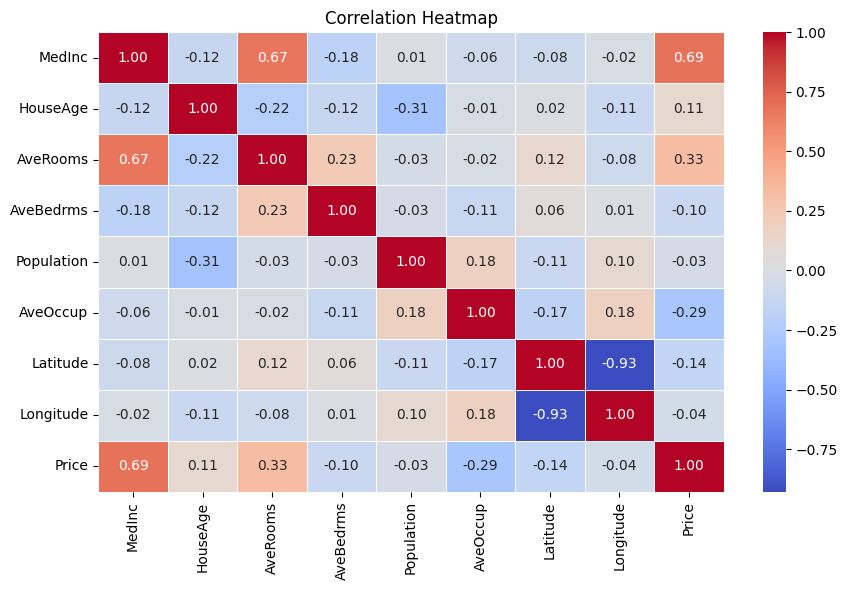

In [10]:
# Plot 4: Correlation Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("plot4_correlation_heatmap.png")
plt.show()

# SECTION 5: FEATURE SELECTION

In [11]:
selected_features = ["MedInc", "HouseAge", "AveRooms", "AveOccup", "Population"]
 
X = df[selected_features]
y = df["Price"]
 
print("Selected features:", selected_features)
print("Feature matrix shape:", X.shape)

Selected features: ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Population']
Feature matrix shape: (20228, 5)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
 
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")


Train size: 16182 | Test size: 4046


# SECTION 7: TRAIN LINEAR REGRESSION

In [13]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
 
y_pred = model.predict(X_test_scaled)
 
print("Model trained successfully.")

Model trained successfully.


# SECTION 8: EVALUATION METRICS

In [14]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)
 
print("\n" + "="*45)
print("  MODEL EVALUATION RESULTS")
print("="*45)
print(f"  MAE  : {mae:.4f}  (avg error = ${mae*100_000:,.0f})")
print(f"  MSE  : {mse:.4f}")
print(f"  RMSE : {rmse:.4f}  (typical error = ${rmse*100_000:,.0f})")
print(f"  R2   : {r2:.4f}  ({r2*100:.1f}% of variance explained)")
print("="*45)


  MODEL EVALUATION RESULTS
  MAE  : 0.5600  (avg error = $56,001)
  MSE  : 0.5912
  RMSE : 0.7689  (typical error = $76,889)
  R2   : 0.5785  (57.8% of variance explained)


# SECTION 9: ACTUAL vs PREDICTED PLOT (Regression Line)

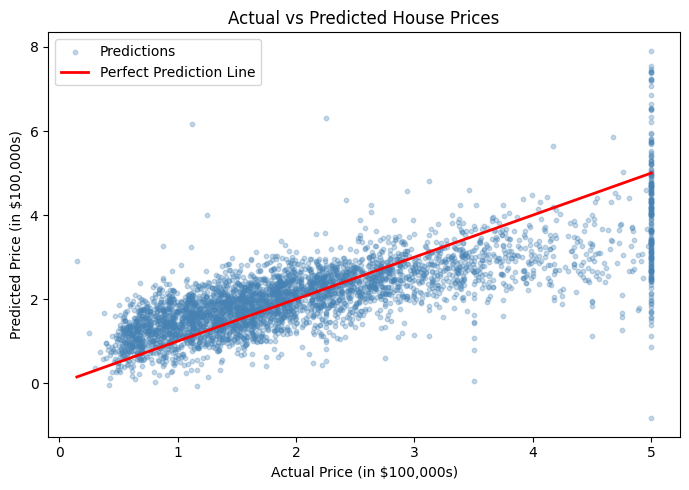

In [15]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color="steelblue", s=10, label="Predictions")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2, label="Perfect Prediction Line"
)
plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual Price (in $100,000s)")
plt.ylabel("Predicted Price (in $100,000s)")
plt.legend()
plt.tight_layout()
plt.savefig("plot5_actual_vs_predicted.png")
plt.show()

# SECTION 10: RESIDUAL PLOTS (Errors)

In [16]:
residuals = y_test - y_pred

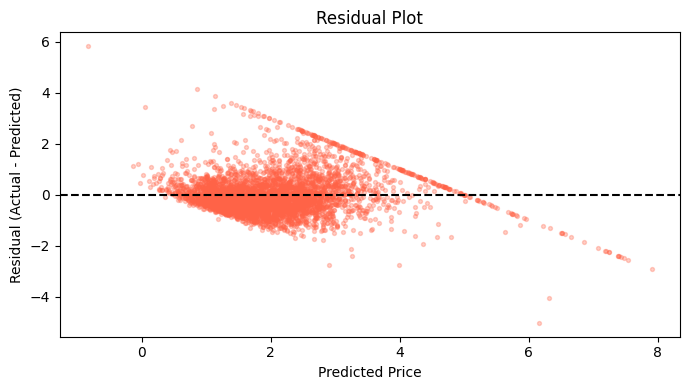

In [17]:
# Residual scatter
plt.figure(figsize=(7, 4))
plt.scatter(y_pred, residuals, alpha=0.3, color="tomato", s=8)
plt.axhline(y=0, color="black", linewidth=1.5, linestyle="--")
plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.tight_layout()
plt.savefig("plot6_residuals.png")
plt.show()

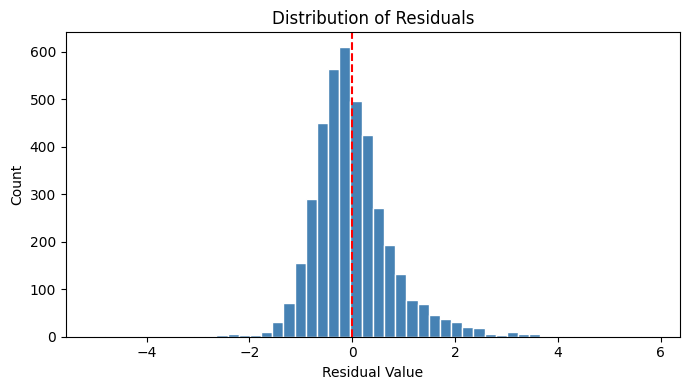

In [18]:
# Residual histogram
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=50, color="steelblue", edgecolor="white")
plt.axvline(x=0, color="red", linewidth=1.5, linestyle="--")
plt.title("Distribution of Residuals")
plt.xlabel("Residual Value")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("plot7_residuals_histogram.png")
plt.show()

# SECTION 11: COEFFICIENT INTERPRETATION

In [19]:
coeff_df = pd.DataFrame({
    "Feature"    : selected_features,
    "Coefficient": model.coef_
}).sort_values("Coefficient", ascending=False)
 
print("\n" + "="*50)
print("  FEATURE COEFFICIENTS")
print("="*50)
print(coeff_df.to_string(index=False))
 
print("\nBusiness Interpretation:")
print("  MedInc     -> Strongest driver. Higher income area = much higher price.")
print("  HouseAge   -> Older homes slightly increase price (established neighborhoods).")
print("  AveRooms   -> More rooms = higher price.")
print("  AveOccup   -> More occupants per household = lower price (overcrowding).")
print("  Population -> Denser areas tend to have slightly lower prices.")


  FEATURE COEFFICIENTS
   Feature  Coefficient
    MedInc     0.952350
  HouseAge     0.205163
Population     0.070158
  AveRooms    -0.219097
  AveOccup    -0.279607

Business Interpretation:
  MedInc     -> Strongest driver. Higher income area = much higher price.
  HouseAge   -> Older homes slightly increase price (established neighborhoods).
  AveRooms   -> More rooms = higher price.
  AveOccup   -> More occupants per household = lower price (overcrowding).
  Population -> Denser areas tend to have slightly lower prices.


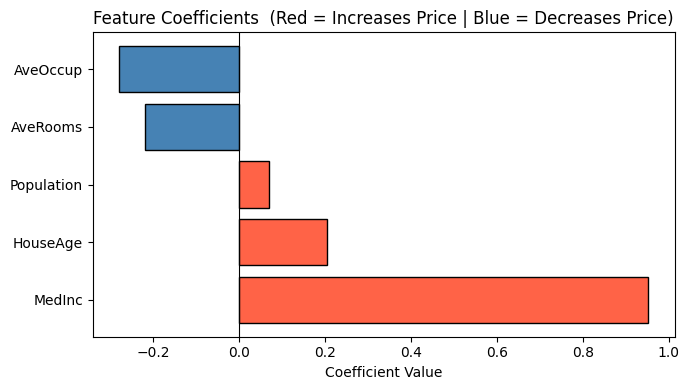

In [20]:
# Coefficient bar chart
plt.figure(figsize=(7, 4))
colors = ["tomato" if c > 0 else "steelblue" for c in coeff_df["Coefficient"]]
plt.barh(coeff_df["Feature"], coeff_df["Coefficient"], color=colors, edgecolor="black")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.title("Feature Coefficients  (Red = Increases Price | Blue = Decreases Price)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("plot8_coefficients.png")
plt.show()

# SECTION 12: FINAL SUMMARY

In [21]:
print("\n" + "="*50)
print("  PROJECT - FINAL SUMMARY")
print("="*50)
print(f"""
Problem  : Predict median house prices in California
Dataset  : California Housing (sklearn built-in, ~20,000 rows)
Target   : Median House Price (in $100,000s)
Model    : Linear Regression
 
Results  :
  MAE  = {mae:.4f}  -> avg prediction off by ${mae*100_000:,.0f}
  RMSE = {rmse:.4f}  -> typical error of ${rmse*100_000:,.0f}
  R2   = {r2:.4f}  -> model explains {r2*100:.1f}% of price variance
 
Key Finding:
  Median income (MedInc) is the strongest predictor of house price.
""")
print("Project complete. 8 plots saved.")



  PROJECT - FINAL SUMMARY

Problem  : Predict median house prices in California
Dataset  : California Housing (sklearn built-in, ~20,000 rows)
Target   : Median House Price (in $100,000s)
Model    : Linear Regression
 
Results  :
  MAE  = 0.5600  -> avg prediction off by $56,001
  RMSE = 0.7689  -> typical error of $76,889
  R2   = 0.5785  -> model explains 57.8% of price variance
 
Key Finding:
  Median income (MedInc) is the strongest predictor of house price.

Project complete. 8 plots saved.
